# Modelos CNN

## Importar librerías

In [25]:
# Librerías básicas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
import shutil
import zipfile

# Librerías para el preprocesamiento de datos
import kagglehub
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Librerías para el modelado
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, ResNet50V2, EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras import layers, models

# Librerías para la evaluación de modelos
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# Clasificación Birds VS Drone

## Cargar datos

In [26]:
# Directorio de trabajo actual
dest_dir = Path(os.getcwd())

# Descargar dataset (devuelve la ruta donde se descargó)
path = kagglehub.dataset_download("stealthknight/bird-vs-drone")

print(f"Dataset descargado en: {path}")

Dataset descargado en: /root/.cache/kagglehub/datasets/stealthknight/bird-vs-drone/versions/1


In [27]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"✅ GPU disponible: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"GPU {i}: {gpu.name}")
else:
    print("⚠️ No hay GPU disponible, se usará CPU")

✅ GPU disponible: 1
GPU 0: /physical_device:GPU:0


## Preparar datasets

In [28]:
# Configuración de paths
dataset_root = dataset_dir if "dataset_dir" in globals() else Path(path) / "Dataset"
train_dir = dataset_root / "train"
val_dir   = dataset_root / "valid"
test_dir  = dataset_root / "test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32


def infer_label_from_filename(image_path):
    """Inferencia por nombre de archivo: B* -> bird(0), D* -> drone(1)."""
    stem_upper = image_path.stem.strip().upper()
    if stem_upper.startswith("B"):
        return 0
    if stem_upper.startswith("D"):
        return 1
    raise ValueError(f"No se pudo inferir clase por nombre en {image_path.name}")


def parse_label_file(label_path, image_path):
    """Parsea etiquetas tipo texto (bird/drone), YOLO (0/1 ...), o fallback por nombre."""
    content = label_path.read_text(encoding="utf-8").strip()

    if not content:
        return infer_label_from_filename(image_path), "filename_fallback"

    first_line = content.splitlines()[0].strip()
    first_token = first_line.split()[0].lower()

    name_to_id = {"bird": 0, "drone": 1}
    if first_token in name_to_id:
        return name_to_id[first_token], "label_text"

    try:
        class_id = int(float(first_token))
    except ValueError as err:
        raise ValueError(
            f"No se pudo parsear etiqueta en {label_path}. "
            f"Primer token: '{first_token}'"
        ) from err

    if class_id not in (0, 1):
        raise ValueError(f"Clase fuera de rango en {label_path}: {class_id}")

    return class_id, "label_yolo"


def create_tf_dataset(split_dir, shuffle=False, seed=42):
    image_dir = split_dir / "images"
    label_dir = split_dir / "labels"

    img_paths = sorted(
        list(image_dir.glob("*.jpg"))
        + list(image_dir.glob("*.jpeg"))
        + list(image_dir.glob("*.png"))
    )
    label_paths = sorted(label_dir.glob("*.txt"))

    label_by_stem = {p.stem: p for p in label_paths}

    image_files = []
    labels = []
    missing_labels = []
    source_counts = {"label_text": 0, "label_yolo": 0, "filename_fallback": 0}

    for img_path in img_paths:
        label_path = label_by_stem.get(img_path.stem)
        if label_path is None:
            missing_labels.append(img_path.name)
            continue

        class_id, source = parse_label_file(label_path, img_path)
        image_files.append(str(img_path))
        labels.append(class_id)
        source_counts[source] += 1

    if missing_labels:
        preview = ", ".join(missing_labels[:5])
        raise ValueError(
            f"Faltan etiquetas para {len(missing_labels)} imágenes en {split_dir.name}. "
            f"Ejemplos: {preview}"
        )

    if not image_files:
        raise ValueError(f"No se encontraron pares imagen-etiqueta válidos en {split_dir}")

    labels_np = np.array(labels, dtype=np.int32)
    class_counts = np.bincount(labels_np, minlength=2)
    print(
        f"[{split_dir.name}] total={len(image_files)} | "
        f"bird(0)={class_counts[0]} | drone(1)={class_counts[1]}"
    )
    print(
        f"[{split_dir.name}] fuente etiquetas -> "
        f"texto={source_counts['label_text']} | "
        f"yolo={source_counts['label_yolo']} | "
        f"fallback_nombre={source_counts['filename_fallback']}"
    )

    ds = tf.data.Dataset.from_tensor_slices((image_files, labels_np))

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_files), seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


# Crear datasets
train_ds = create_tf_dataset(train_dir, shuffle=True)
val_ds   = create_tf_dataset(val_dir, shuffle=False)
test_ds  = create_tf_dataset(test_dir, shuffle=False)

[train] total=18323 | bird(0)=18320 | drone(1)=3
[train] fuente etiquetas -> texto=0 | yolo=18306 | fallback_nombre=17
[valid] total=1740 | bird(0)=1739 | drone(1)=1
[valid] fuente etiquetas -> texto=0 | yolo=1737 | fallback_nombre=3
[test] total=889 | bird(0)=798 | drone(1)=91
[test] fuente etiquetas -> texto=0 | yolo=886 | fallback_nombre=3


In [29]:
def get_model(model_name, input_shape=(224,224,3), num_classes=2):
    if model_name=="ResNet50":
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name=="MobileNetV2":
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name=="EfficientNetB0":
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    
    base.trainable = False  # freeze pre-trained layers
    
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Sistema de registro de experimentos

In [30]:
# ── Registro de experimentos ────────────────────────────────────────────────
experiment_registry = []
history_registry    = {}

def run_experiment(model_name, train_ds, val_ds, test_ds, epochs=5):
    """Entrena un modelo, evalúa y registra resultados."""
    print(f"\n{'='*50}")
    print(f"  Experimento: {model_name}")
    print(f"{'='*50}")

    model = get_model(model_name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    # Predicciones para métricas adicionales
    y_pred, y_true = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    record = {
        'model':     model_name,
        'epochs':    epochs,
        'test_loss': round(loss, 4),
        'test_acc':  round(acc,  4),
        'val_acc':   round(max(history.history['val_accuracy']), 4),
        'val_loss':  round(min(history.history['val_loss']),     4),
    }

    experiment_registry.append(record)
    history_registry[model_name] = history.history

    print(f"✅ {model_name} → Acc: {acc:.4f} | Loss: {loss:.4f}")
    return model, y_true, y_pred


In [31]:
# ── Ejecutar todos los modelos ───────────────────────────────────────────────
models_to_test = ["ResNet50", "MobileNetV2", "EfficientNetB0"]
predictions_registry = {}

for model_name in models_to_test:
    model, y_true, y_pred = run_experiment(
        model_name, train_ds, val_ds, test_ds, epochs=5
    )
    predictions_registry[model_name] = {'y_true': y_true, 'y_pred': y_pred}



  Experimento: ResNet50
Epoch 1/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9987 - loss: 0.0088 - val_accuracy: 0.9994 - val_loss: 0.0079
Epoch 2/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 0.9994 - val_loss: 0.0094
Epoch 3/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.9997 - loss: 0.0058 - val_accuracy: 0.9994 - val_loss: 0.0074
Epoch 4/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.9999 - loss: 7.1992e-04 - val_accuracy: 0.9994 - val_loss: 0.0068
Epoch 5/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.9997 - loss: 0.0041 - val_accuracy: 0.9994 - val_loss: 0.0050


2026-03-12 13:32:01.897889: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


✅ ResNet50 → Acc: 0.8976 | Loss: 0.9110

  Experimento: MobileNetV2
Epoch 1/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.9884 - loss: 0.0332 - val_accuracy: 0.9994 - val_loss: 0.0090
Epoch 2/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9997 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0080
Epoch 3/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9999 - loss: 5.1861e-04 - val_accuracy: 0.9994 - val_loss: 0.0042
Epoch 4/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 0.9994 - val_loss: 0.0085
Epoch 5/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 0.9994 - val_loss: 0.0088


2026-03-12 13:33:57.890157: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


✅ MobileNetV2 → Acc: 0.8976 | Loss: 1.8135

  Experimento: EfficientNetB0
Epoch 1/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 56s 56ms/step - accuracy: 0.9901 - loss: 0.0345 - val_accuracy: 0.9994 - val_loss: 0.0073
Epoch 2/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9996 - loss: 0.0043 - val_accuracy: 0.9994 - val_loss: 0.0067
Epoch 3/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9994 - val_loss: 0.0073
Epoch 4/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9994 - val_loss: 0.0064
Epoch 5/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9999 - loss: 0.0018 - val_accuracy: 0.9994 - val_loss: 0.0048
✅ EfficientNetB0 → Acc: 0.8976 | Loss: 0.7556


2026-03-12 13:36:40.549413: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [32]:
# ── Ranking de resultados ────────────────────────────────────────────────────
results_df = pd.DataFrame(experiment_registry).sort_values('test_acc', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1  # ranking desde 1
print("Ranking de modelos:")
results_df


Ranking de modelos:


,model,epochs,test_loss,test_acc,val_acc,val_loss
1,ResNet50,5,0.9110,0.8976,0.9994,0.0050
2,MobileNetV2,5,1.8135,0.8976,0.9994,0.0042
3,EfficientNetB0,5,0.7556,0.8976,0.9994,0.0048


## Matrices de confusión comparadas

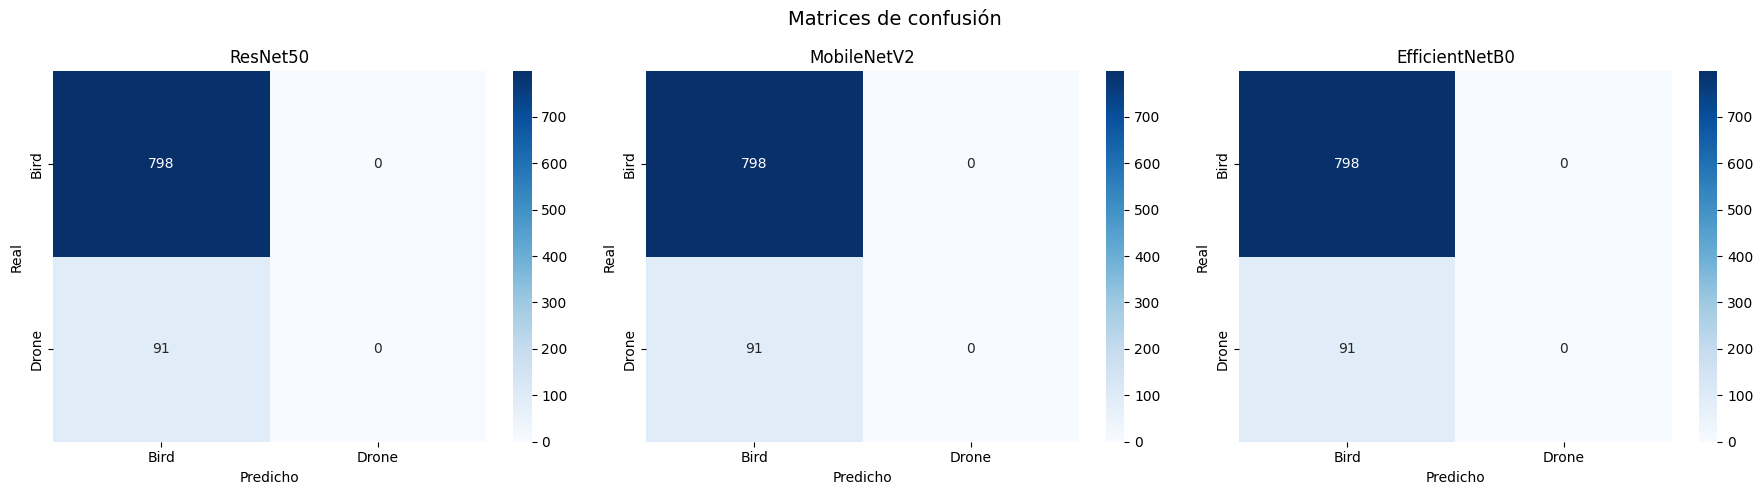

In [33]:
# ── Matrices de confusión ────────────────────────────────────────────────────
class_names = ['Bird', 'Drone']
n = len(predictions_registry)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

for ax, (model_name, preds) in zip(axes, predictions_registry.items()):
    cm = confusion_matrix(preds['y_true'], preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión', fontsize=14)
plt.tight_layout()
plt.show()


## Reporte de los modelos

In [34]:


for model_name, preds in predictions_registry.items():
    y_true = np.array(preds["y_true"])
    y_pred = np.array(preds["y_pred"])

    print(f"\n=== {model_name} ===")
    print("Reales     [bird, drone]:", np.bincount(y_true, minlength=2))
    print("Predichas  [bird, drone]:", np.bincount(y_pred, minlength=2))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("CM [[TN, FP],[FN, TP]]:\n", cm)


=== ResNet50 ===
Reales     [bird, drone]: [798  91]
Predichas  [bird, drone]: [889   0]
CM [[TN, FP],[FN, TP]]:
 [[798   0]
 [ 91   0]]

=== MobileNetV2 ===
Reales     [bird, drone]: [798  91]
Predichas  [bird, drone]: [889   0]
CM [[TN, FP],[FN, TP]]:
 [[798   0]
 [ 91   0]]

=== EfficientNetB0 ===
Reales     [bird, drone]: [798  91]
Predichas  [bird, drone]: [889   0]
CM [[TN, FP],[FN, TP]]:
 [[798   0]
 [ 91   0]]


## Conclusiones Clasificación Bird VS Drone

En base a los resultados obtenidos con ResNet50, MobileNetV2 y EfficientNetB0, se concluye que:

- El conjunto de prueba contiene 798 imágenes de `bird` y 91 de `drone` (clases reales).
- Los tres modelos solo predicen la clase mayoritaria: 889 como `bird` y 0 como `drone`.
- Esto sugiere un problema de desbalance y/o calidad de etiquetado en el dataset, por lo que la `accuracy` no refleja bien el rendimiento real.

## Probar `transfer learning`

In [35]:
# Preprocesado específico para ResNet50V2
def prepare_for_resnet_v2(ds):
    return ds.map(
        lambda x, y: (preprocess_input(x * 255.0), y),
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

train_tl_ds = prepare_for_resnet_v2(train_ds)
val_tl_ds   = prepare_for_resnet_v2(val_ds)
test_tl_ds  = prepare_for_resnet_v2(test_ds)

# class_weight para mitigar desbalance
y_train_all = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
class_counts = np.bincount(y_train_all, minlength=2)
total = class_counts.sum()

class_weight = {
    0: total / (2 * class_counts[0]),
    1: total / (2 * class_counts[1]) if class_counts[1] > 0 else 1.0
}

print("class_counts:", class_counts)
print("class_weight:", class_weight)

# Modelo base
base_model = ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# Cabeza de clasificación
inputs = tf.keras.Input(shape=(224, 224, 3))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.05)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation="softmax")(x)

tl_model = tf.keras.Model(inputs, outputs, name="ResNet50V2_transfer")

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_1 = tl_model.fit(
    train_tl_ds,
    validation_data=val_tl_ds,
    epochs=5,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

# Fine-tuning: desbloquear últimas capas
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_2 = tl_model.fit(
    train_tl_ds,
    validation_data=val_tl_ds,
    epochs=3,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

# Evaluación
loss, acc = tl_model.evaluate(test_tl_ds, verbose=0)
print(f"\nTransfer Learning - ResNet50V2 | Test Acc: {acc:.4f} | Test Loss: {loss:.4f}")

y_true, y_pred = [], []
for images, labels in test_tl_ds:
    preds = tl_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nPredichas [bird, drone]:", np.bincount(np.array(y_pred), minlength=2))
print("Reales    [bird, drone]:", np.bincount(np.array(y_true), minlength=2))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nMatriz de confusión:\n", cm)

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=["Bird", "Drone"]))

2026-03-12 13:36:47.276403: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


class_counts: [18320     3]
class_weight: {0: 0.5000818777292576, 1: 3053.8333333333335}
Epoch 1/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.9874 - loss: 7.9876 - val_accuracy: 0.9994 - val_loss: 0.0054
Epoch 2/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.9330 - loss: 2.9634 - val_accuracy: 0.9994 - val_loss: 0.0096
Epoch 3/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.9493 - loss: 0.4503 - val_accuracy: 0.9994 - val_loss: 0.0122
Epoch 1/3
573/573 ━━━━━━━━━━━━━━━━━━━━ 75s 108ms/step - accuracy: 0.9999 - loss: 2.9904 - val_accuracy: 0.9994 - val_loss: 0.0079
Epoch 2/3
573/573 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 1.0000 - loss: 0.2836 - val_accuracy: 0.9994 - val_loss: 0.0080

Transfer Learning - ResNet50V2 | Test Acc: 0.8976 | Test Loss: 2.0190

Predichas [bird, drone]: [889   0]
Reales    [bird, drone]: [798  91]

Matriz de confusión:
 [[798   0]
 [ 91   0]]

Reporte de clasificación:
              precision    recall  f1-score   sup

2026-03-12 13:41:47.286626: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

# Clasificación Multiclase

## Cargar datos

In [36]:
# Download latest version
path = kagglehub.dataset_download("imsparsh/flowers-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2


In [37]:
flowers_root = Path(path)
print('Raíz:', flowers_root)
print('\nContenido raíz:')
for item in sorted(flowers_root.iterdir()):
    print('-', item.name)

print('\nSubcarpetas train (primer nivel):')
for item in sorted((flowers_root / 'train').iterdir())[:20]:
    print('-', item.name)

print('\nCSV test:')
display(pd.read_csv(flowers_root / 'Testing_set_flower.csv').head())

Raíz: /root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2

Contenido raíz:
- LICENSE.txt
- Testing_set_flower.csv
- sample_submission.csv
- test
- train

Subcarpetas train (primer nivel):
- daisy
- dandelion
- rose
- sunflower
- tulip

CSV test:


,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg


## Preparar dataset de flores

In [41]:
flowers_root = Path(path)
flowers_train_dir = flowers_root / 'train'
flowers_test_dir = flowers_root / 'test'
flowers_test_csv = flowers_root / 'Testing_set_flower.csv'
flowers_submission_csv = flowers_root / 'sample_submission.csv'

FLOWERS_IMG_SIZE = (224, 224)
FLOWERS_BATCH_SIZE = 32
FLOWERS_SEED = 42

flowers_train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    flowers_train_dir,
    validation_split=0.2,
    subset='training',
    seed=FLOWERS_SEED,
    image_size=FLOWERS_IMG_SIZE,
    batch_size=FLOWERS_BATCH_SIZE,
    label_mode='int'
 )

flowers_val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    flowers_train_dir,
    validation_split=0.2,
    subset='validation',
    seed=FLOWERS_SEED,
    image_size=FLOWERS_IMG_SIZE,
    batch_size=FLOWERS_BATCH_SIZE,
    label_mode='int'
 )

flowers_class_names = flowers_train_ds_raw.class_names
num_flowers_classes = len(flowers_class_names)

AUTOTUNE = tf.data.AUTOTUNE
flowers_train_ds = flowers_train_ds_raw.prefetch(AUTOTUNE)
flowers_val_ds = flowers_val_ds_raw.prefetch(AUTOTUNE)

print('Clases:', flowers_class_names)
print('Número de clases:', num_flowers_classes)
print('CSV submission ejemplo:')
display(pd.read_csv(flowers_submission_csv).head())

flowers_test_df = pd.read_csv(flowers_test_csv)
flowers_test_paths = [str(flowers_test_dir / fname) for fname in flowers_test_df['filename']]
print('Imágenes de test sin etiqueta:', len(flowers_test_paths))

Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Clases: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Número de clases: 5
CSV submission ejemplo:


,prediction
0,sunflower
1,sunflower
2,sunflower
3,sunflower
4,sunflower


Imágenes de test sin etiqueta: 924


## Comparación de modelos multiclase

In [42]:
multiclass_experiment_registry = []
multiclass_history_registry = {}
multiclass_predictions_registry = {}

def get_multiclass_model(model_name, input_shape=(224, 224, 3), num_classes=5):
    if model_name == 'ResNet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'MobileNetV2':
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'EfficientNetB0':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f'Modelo no soportado: {model_name}')

    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255.0)(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name=f'{model_name}_multiclass')
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def run_multiclass_experiment(model_name, train_ds, val_ds, class_names, epochs=5):
    print(f"\n{'='*60}")
    print(f'  Experimento multiclase: {model_name}')
    print(f"{'='*60}")

    model = get_multiclass_model(
        model_name,
        input_shape=(FLOWERS_IMG_SIZE[0], FLOWERS_IMG_SIZE[1], 3),
        num_classes=len(class_names)
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(val_ds, verbose=0)

    y_true, y_pred = [], []
    for images, labels in val_ds:
        probs = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())

    record = {
        'model': model_name,
        'epochs': epochs,
        'val_loss': round(val_loss, 4),
        'val_acc': round(val_acc, 4),
        'best_val_acc': round(max(history.history['val_accuracy']), 4),
        'best_val_loss': round(min(history.history['val_loss']), 4),
    }

    multiclass_experiment_registry.append(record)
    multiclass_history_registry[model_name] = history.history
    multiclass_predictions_registry[model_name] = {
        'y_true': np.array(y_true),
        'y_pred': np.array(y_pred),
    }

    print(f'✅ {model_name} → Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}')
    return model

In [43]:
multiclass_models_to_test = ['ResNet50', 'MobileNetV2', 'EfficientNetB0']
multiclass_trained_models = {}

for model_name in multiclass_models_to_test:
    trained_model = run_multiclass_experiment(
        model_name,
        flowers_train_ds,
        flowers_val_ds,
        flowers_class_names,
        epochs=5
    )
    multiclass_trained_models[model_name] = trained_model


  Experimento multiclase: ResNet50
Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.2570 - loss: 1.6773 - val_accuracy: 0.3497 - val_loss: 1.4933
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3511 - loss: 1.5080 - val_accuracy: 0.3862 - val_loss: 1.4558
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3571 - loss: 1.5008 - val_accuracy: 0.4117 - val_loss: 1.4644
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3603 - loss: 1.4993 - val_accuracy: 0.4208 - val_loss: 1.4515
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3620 - loss: 1.4745 - val_accuracy: 0.4299 - val_loss: 1.4419


2026-03-12 13:52:53.223761: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


✅ ResNet50 → Val Acc: 0.4299 | Val Loss: 1.4365

  Experimento multiclase: MobileNetV2
Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.6414 - loss: 0.9313 - val_accuracy: 0.8670 - val_loss: 0.3903
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8842 - loss: 0.3343 - val_accuracy: 0.8798 - val_loss: 0.3760
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9148 - loss: 0.2319 - val_accuracy: 0.8816 - val_loss: 0.3366
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9538 - loss: 0.1563 - val_accuracy: 0.8998 - val_loss: 0.3248
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9536 - loss: 0.1355 - val_accuracy: 0.9107 - val_loss: 0.3124


2026-03-12 13:53:19.285008: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


✅ MobileNetV2 → Val Acc: 0.9107 | Val Loss: 0.3326

  Experimento multiclase: EfficientNetB0
Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 35s 252ms/step - accuracy: 0.1992 - loss: 1.6174 - val_accuracy: 0.2495 - val_loss: 1.6015
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2341 - loss: 1.6075 - val_accuracy: 0.2495 - val_loss: 1.5989
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.2198 - loss: 1.6100 - val_accuracy: 0.2495 - val_loss: 1.5964
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.2258 - loss: 1.6070 - val_accuracy: 0.2495 - val_loss: 1.5956
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.2287 - loss: 1.6062 - val_accuracy: 0.2495 - val_loss: 1.6009
✅ EfficientNetB0 → Val Acc: 0.2495 | Val Loss: 1.5937


2026-03-12 13:54:17.124995: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [44]:
multiclass_results_df = pd.DataFrame(multiclass_experiment_registry).sort_values('val_acc', ascending=False)
multiclass_results_df = multiclass_results_df.reset_index(drop=True)
multiclass_results_df.index += 1
print('Ranking de modelos multiclase:')
multiclass_results_df

Ranking de modelos multiclase:


,model,epochs,val_loss,val_acc,best_val_acc,best_val_loss
1,MobileNetV2,5,0.3326,0.9107,0.9107,0.3124
2,ResNet50,5,1.4365,0.4299,0.4299,1.4419
3,EfficientNetB0,5,1.5937,0.2495,0.2495,1.5956


In [45]:
best_model_name = multiclass_results_df.iloc[0]['model']
best_preds = multiclass_predictions_registry[best_model_name]

print(f'Mejor modelo (según val_acc): {best_model_name}')
print(classification_report(
    best_preds['y_true'],
    best_preds['y_pred'],
    target_names=flowers_class_names,
    zero_division=0,
    digits=4
))

Mejor modelo (según val_acc): MobileNetV2
              precision    recall  f1-score   support

       daisy     0.9605    0.8795    0.9182        83
   dandelion     0.9291    0.9562    0.9424       137
        rose     0.8889    0.8544    0.8713       103
   sunflower     0.9462    0.9462    0.9462        93
       tulip     0.8571    0.9023    0.8791       133

    accuracy                         0.9107       549
   macro avg     0.9164    0.9077    0.9115       549
weighted avg     0.9118    0.9107    0.9107       549



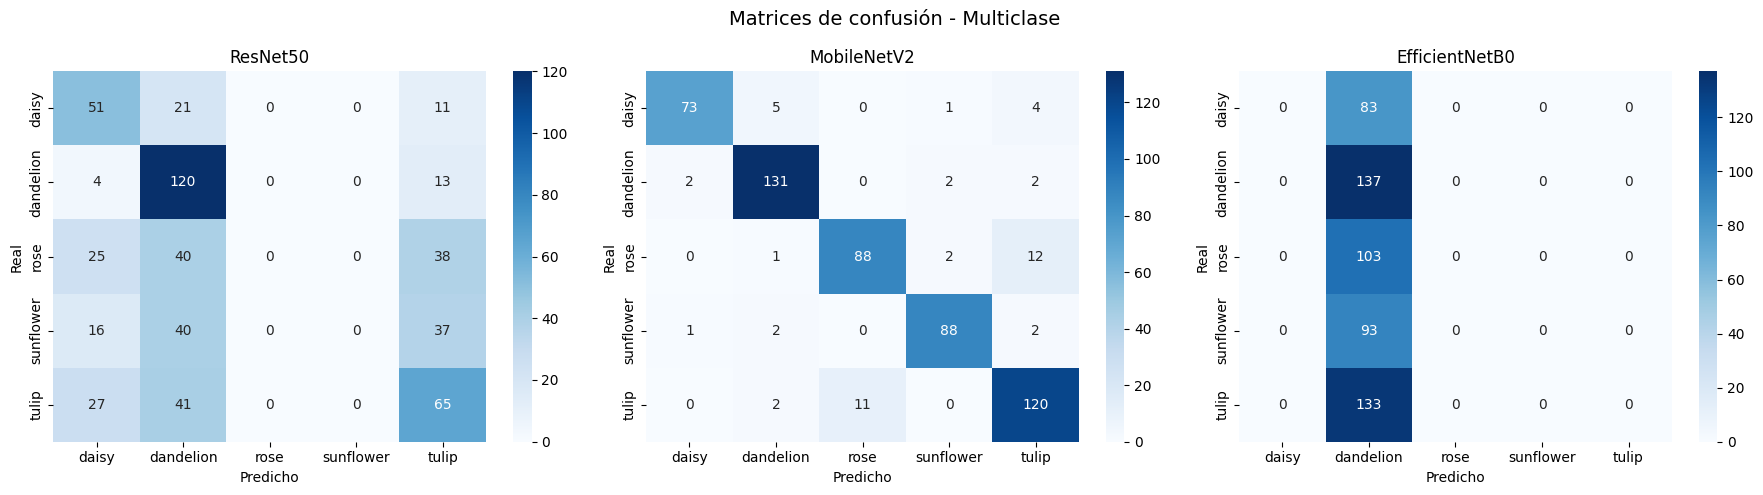

In [46]:
n_models = len(multiclass_predictions_registry)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

if n_models == 1:
    axes = [axes]

for ax, (model_name, preds) in zip(axes, multiclass_predictions_registry.items()):
    cm = confusion_matrix(preds['y_true'], preds['y_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=flowers_class_names,
        yticklabels=flowers_class_names,
        ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión - Multiclase', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusiones Clasificación Multiclase